In [2]:
import numpy as np # processamento de array
import matplotlib.pyplot as plt # visualização de dados
import cv2 # processamento de imagens
from pathlib import Path # manipulação de caminhos de arquivos
from PIL import Image # manipulação de imagens

from sklearn.model_selection import train_test_split # divisão de dados
from sklearn.ensemble import RandomForestClassifier # modelo de classificação
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay # avaliação de modelo

from tensorflow.keras.models import Sequential # modelo de rede neural
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Input # camadas de rede neural
from tensorflow.keras.optimizers import Adam # otimizador

## Importando os Dados

# Projeto Extra: Classificação de AVC em Tomografias (CT)

**Base**: Kaggle Brain Stroke CT Image Dataset  
**Objetivo**: Classificação binária (AVC vs não-AVC) a partir de imagens de tomografia computadorizada.

**Modelos comparados**:
1. RandomForestClassifier (scikit-learn)
2. Rede Neural Tradicional MLP/Dense (TensorFlow)
3. Rede Neural Convolucional CNN (TensorFlow)

In [3]:

# definição do dataset do Kaggle
dataset_slug = "afridirahman/brain-stroke-ct-image-dataset"

try:
    import kagglehub
except ImportError:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "kagglehub"])
    import kagglehub

# baixa a última versão do dataset
dataset_path = kagglehub.dataset_download(dataset_slug)
print("Caminho para os arquivos do dataset:", dataset_path)

# função para encontrar o diretório raiz do dataset
def find_class_root(base_path):
    """Procura o diretório contendo >= 2 subpastas com imagens (classes)."""
    base = Path(base_path)
    candidates = [base] + [d for d in base.rglob("*") if d.is_dir()]
    for d in candidates:
        subdirs = [p for p in d.iterdir() if p.is_dir()]
        if len(subdirs) >= 2:
            valid = sum(1 for sd in subdirs 
                       if any(sd.glob("**/*.png")) or any(sd.glob("**/*.jpg")) or any(sd.glob("**/*.jpeg")))
            if valid >= 2:
                return d
    return base

dataset_root = find_class_root(dataset_path)
print("Diretório raiz detectado:", dataset_root)

Caminho para os arquivos do dataset: /home/paulo/.cache/kagglehub/datasets/afridirahman/brain-stroke-ct-image-dataset/versions/1
Diretório raiz detectado: /home/paulo/.cache/kagglehub/datasets/afridirahman/brain-stroke-ct-image-dataset/versions/1/Brain_Data_Organised


## Carregamento e pré-processamento das imagens

In [4]:
IMG_SIZE = 128

# lista classes a partir dos diretórios
classes = sorted([p.name for p in Path(dataset_root).iterdir() if p.is_dir()])
print("Classes detectadas:", classes)

# mapeamento de labels
# exemplos de nomes que indicam AVC: "stroke", "Stroke", "abnormal", "positive", etc.
stroke_keywords = {"stroke", "abnormal", "positive", "hemorrhagic", "ischemic"}

# função para determinar se a classe indica AVC
def is_stroke_class(class_name):
    return any(kw in class_name.lower() for kw in stroke_keywords)

label_map = {cls: 1 if is_stroke_class(cls) else 0 for cls in classes}
print("Mapeamento de labels:", label_map)

# função para carregar imagens em grayscale, redimensiona e retorna X, y.
def load_images_labels(root_path, img_size=IMG_SIZE):
    X, y = [], []
    root = Path(root_path)
    valid_ext = {'.png', '.jpg', '.jpeg', '.bmp'}
    
    for cls in classes:
        cls_dir = root / cls
        for f in cls_dir.rglob('*'):
            if f.suffix.lower() in valid_ext:
                try:
                    img = Image.open(f).convert('L').resize((img_size, img_size))
                    X.append(np.asarray(img, dtype=np.uint8))
                    y.append(label_map[cls])
                except Exception:
                    pass  # Ignora arquivos corrompidos
    
    X = np.array(X)
    y = np.array(y)
    print(f"Total de imagens carregadas: {len(X)}")
    print(f"Distribuição das classes: 0 (não-AVC)={np.sum(y==0)}, 1 (AVC)={np.sum(y==1)}")
    return X, y

X, y = load_images_labels(dataset_root)
print("Shape das imagens:", X.shape)

# normalização [0, 1]
X_norm = X.astype(np.float32) / 255.0

# split estratificado treino/teste
X_train, X_test, y_train, y_test = train_test_split(
    X_norm, y, test_size=0.2, stratify=y, random_state=42
)
print(f"Treino: {len(X_train)} | Teste: {len(X_test)}")

Classes detectadas: ['Normal', 'Stroke']
Mapeamento de labels: {'Normal': 0, 'Stroke': 1}
Total de imagens carregadas: 2501
Distribuição das classes: 0 (não-AVC)=1551, 1 (AVC)=950
Shape das imagens: (2501, 128, 128)
Treino: 2000 | Teste: 501


## Visualização de amostras e filtros

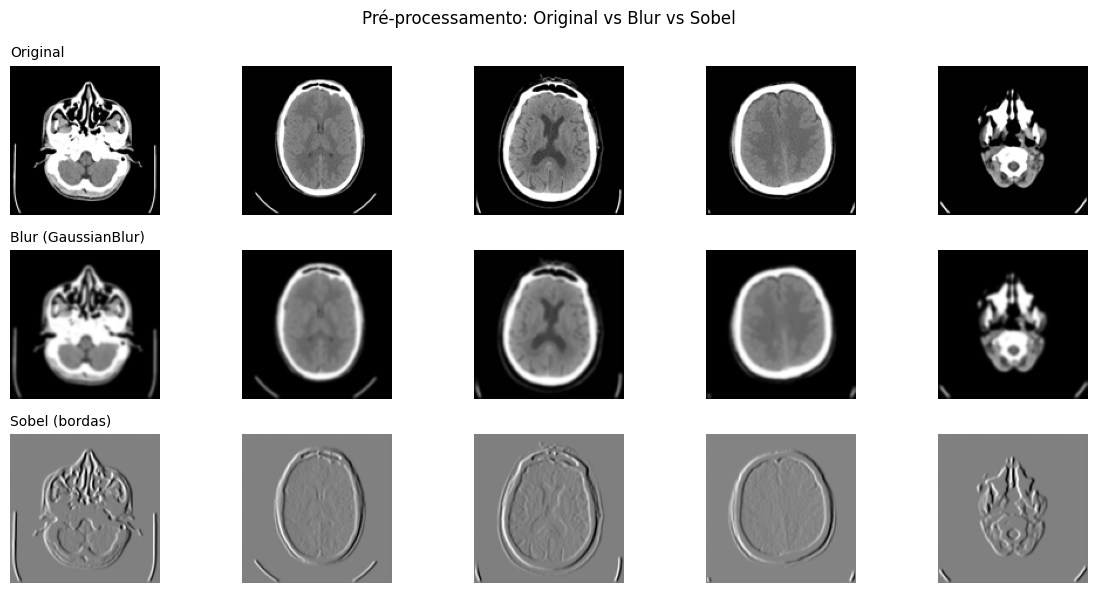

In [5]:
sample_images = X_train[:5]

# aplicação de filtros: blur e sobel
filtered_images = {
    'original': sample_images,
    'blurred': np.array([cv2.GaussianBlur(img, (5, 5), 0) for img in sample_images]),
    'sobel': np.array([cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3) for img in sample_images])
}

# visualização dos resultados
fig, axs = plt.subplots(3, 5, figsize=(12, 6))
titles = ['Original', 'Blur (GaussianBlur)', 'Sobel (bordas)']

# preenchimento das imagens nos subplots
for i in range(5):
    axs[0, i].imshow(filtered_images['original'][i], cmap='gray')
    axs[1, i].imshow(filtered_images['blurred'][i], cmap='gray')
    axs[2, i].imshow(filtered_images['sobel'][i], cmap='gray')
    for j in range(3):
        axs[j, i].axis('off')

# adiciona títulos às linhas
for row, title in zip(axs[:, 0], titles):
    row.set_title(title, fontsize=10, loc='left')

plt.suptitle("Pré-processamento: Original vs Blur vs Sobel", fontsize=12)
plt.tight_layout()
plt.show()

## Modelo 1: RandomForestClassifier

In [6]:
# Flatten das imagens para o RandomForest
X_train_flat = X_train.reshape(len(X_train), -1)
X_test_flat = X_test.reshape(len(X_test), -1)
print(f"Shape flatten: {X_train_flat.shape}")

# treinamento do modelo RandomForestClassifier
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)
rf.fit(X_train_flat, y_train)

y_pred_rf = rf.predict(X_test_flat)
acc_rf = accuracy_score(y_test, y_pred_rf)
print(f"\nAcurácia - RandomForest: {acc_rf:.4f}")

print("\nRelatório de classificação (RandomForest):")
print(classification_report(y_test, y_pred_rf, target_names=['não-AVC', 'AVC']))

Shape flatten: (2000, 16384)

Acurácia - RandomForest: 0.9701

Relatório de classificação (RandomForest):
              precision    recall  f1-score   support

     não-AVC       0.95      1.00      0.98       311
         AVC       1.00      0.92      0.96       190

    accuracy                           0.97       501
   macro avg       0.98      0.96      0.97       501
weighted avg       0.97      0.97      0.97       501



## Modelo 2: Rede Neural Tradicional (MLP/Dense) - TensorFlow

In [7]:
# modelo MLP/Dense - TensorFlow
model_mlp = Sequential([
    Dense(256, activation='relu', input_shape=(IMG_SIZE * IMG_SIZE,)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')  # Saída binária
])

# compilação do modelo
model_mlp.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Treinando MLP/Dense...")
history_mlp = model_mlp.fit(
    X_train_flat, y_train,
    validation_split=0.1,
    epochs=10,
    batch_size=32,
    verbose=1
)

loss_mlp, acc_mlp = model_mlp.evaluate(X_test_flat, y_test, verbose=0)
print(f"\nAcurácia - Rede Neural Tradicional (MLP): {acc_mlp:.4f}")

Treinando MLP/Dense...


/home/paulo/workspaces/fiap-pos-tech-ia-para-devs/01-aulas-gravadas/01-welcome-to-ia-para-devs/07-tech-challenge/cnn-computer-vision/venv/lib64/python3.13/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.6428 - loss: 0.6814 - val_accuracy: 0.6750 - val_loss: 0.6062
Epoch 2/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8183 - loss: 0.4127 - val_accuracy: 0.7200 - val_loss: 0.5547
Epoch 3/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8394 - loss: 0.3520 - val_accuracy: 0.8300 - val_loss: 0.3903
Epoch 4/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9133 - loss: 0.2275 - val_accuracy: 0.8700 - val_loss: 0.2859
Epoch 5/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9356 - loss: 0.1654 - val_accuracy: 0.8950 - val_loss: 0.2230
Epoch 6/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9572 - loss: 0.1183 - val_accuracy: 0.8950 - val_loss: 0.2013
Epoch 7/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9433 - loss: 0.1427 - val_accuracy: 0.9200 - val_loss: 0.1871
Epoch 8/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9578 - loss: 0.1014 - val_accuracy: 0.9200 - v

## Modelo 3: Rede Neural Convolucional (CNN) - TensorFlow

In [8]:
# reshape para CNN: (N, 128, 128, 1)
X_train_cnn = X_train.reshape(-1, IMG_SIZE, IMG_SIZE, 1)
X_test_cnn = X_test.reshape(-1, IMG_SIZE, IMG_SIZE, 1)
print(f"Shape para CNN: {X_train_cnn.shape}")

model_cnn = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid')  # Saída binária
])

model_cnn.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Treinando CNN...")
history_cnn = model_cnn.fit(
    X_train_cnn, y_train,
    validation_split=0.1,
    epochs=50,
    batch_size=32,
    verbose=1
)

loss_cnn, acc_cnn = model_cnn.evaluate(X_test_cnn, y_test, verbose=0)
print(f"\nAcurácia - CNN (TensorFlow): {acc_cnn:.4f}")

Shape para CNN: (2000, 128, 128, 1)
Treinando CNN...
Epoch 1/50


/home/paulo/workspaces/fiap-pos-tech-ia-para-devs/01-aulas-gravadas/01-welcome-to-ia-para-devs/07-tech-challenge/cnn-computer-vision/venv/lib64/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 75ms/step - accuracy: 0.6400 - loss: 0.6536 - val_accuracy: 0.7000 - val_loss: 0.6016
Epoch 2/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 72ms/step - accuracy: 0.7211 - loss: 0.5376 - val_accuracy: 0.7850 - val_loss: 0.4566
Epoch 3/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 72ms/step - accuracy: 0.8383 - loss: 0.3467 - val_accuracy: 0.8600 - val_loss: 0.3313
Epoch 4/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 72ms/step - accuracy: 0.9067 - loss: 0.2202 - val_accuracy: 0.8900 - val_loss: 0.2742
Epoch 5/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 75ms/step - accuracy: 0.9494 - loss: 0.1308 - val_accuracy: 0.9050 - val_loss: 0.2379
Epoch 6/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 73ms/step - accuracy: 0.9511 - loss: 0.1161 - val_accuracy: 0.9350 - val_loss: 0.1989
Epoch 7/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 73ms/step - accuracy: 0.9822 - loss: 0.0548 - val_accuracy: 0.9250 - val_loss: 0.1854
Epoch 8/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 73ms/step - accuracy: 0.9894 - loss: 0.0296 - val_accuracy: 0.9350 - val_loss: 0.

## Comparação Final dos Modelos


COMPARAÇÃO DE ACURÁCIA - Classificação de AVC (CT)
RandomForest:                    0.9701
Rede Neural Tradicional (MLP):   0.9042
Rede Neural Convolucional (CNN): 0.9541


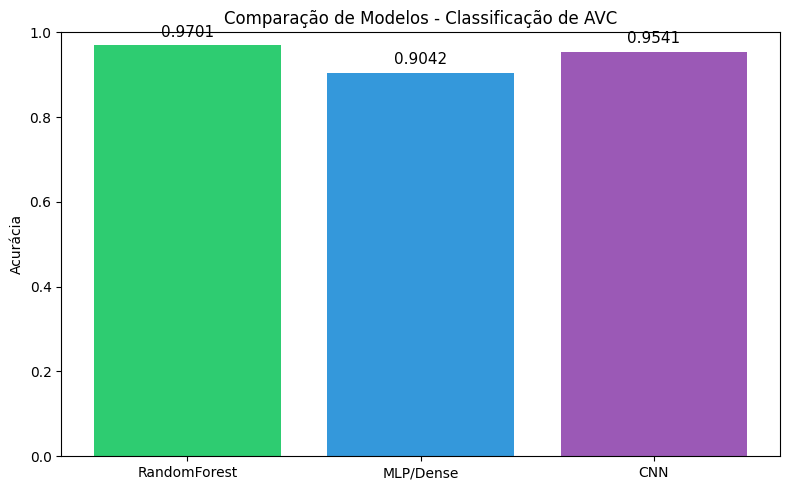

In [9]:
print("\n" + "="*50)
print("COMPARAÇÃO DE ACURÁCIA - Classificação de AVC (CT)")
print("="*50)
print(f"RandomForest:                    {acc_rf:.4f}")
print(f"Rede Neural Tradicional (MLP):   {acc_mlp:.4f}")
print(f"Rede Neural Convolucional (CNN): {acc_cnn:.4f}")
print("="*50)

# gráfico comparativo
modelos = ['RandomForest', 'MLP/Dense', 'CNN']
acuracias = [acc_rf, acc_mlp, acc_cnn]

plt.figure(figsize=(8, 5))
bars = plt.bar(modelos, acuracias, color=['#2ecc71', '#3498db', '#9b59b6'])
plt.ylim(0, 1)
plt.ylabel('Acurácia')
plt.title('Comparação de Modelos - Classificação de AVC')

for bar, acc in zip(bars, acuracias):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
             f'{acc:.4f}', ha='center', fontsize=11)

plt.tight_layout()
plt.show()